# Исследование KNN
Датасет: Wine. \
13 числовых характеристик вина, 3 различных класса.

### Импорт библиотек

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report,
)
from sklearn.preprocessing import MinMaxScaler

In [2]:
df = datasets.load_wine()
X = df.data
y = df.target
feature_names = df.feature_names
class_names = df.target_names
n_features = X.shape[1]

In [3]:
wine_df = pd.DataFrame(data=X, columns=df.feature_names)
wine_df['target'] = y

In [4]:
def describe_df(df):
    display(df.head())
    print("Dataset size:")
    display(df.shape)
    print("Data types:")
    display(df.dtypes)
    print("Missing values:")
    display(df.isnull().sum())
    display(df.describe())

In [5]:
describe_df(wine_df)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Dataset size:


(178, 14)

Data types:


alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
target                            int64
dtype: object

Missing values:


alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
target                          0
dtype: int64

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [6]:
def get_classes_plots(df):
    classes = df['target'].value_counts()
    classes_dist = pd.DataFrame(data = classes)
    display(classes_dist)
  
    sns.countplot(data=df, x='target')
    plt.show()

,count
target,
1,71
0,59
2,48


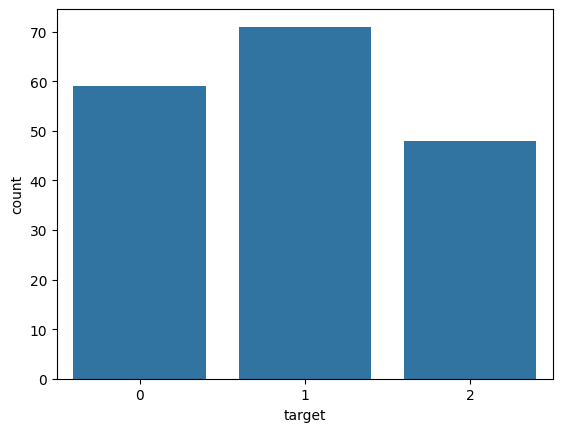

In [7]:
get_classes_plots(wine_df)

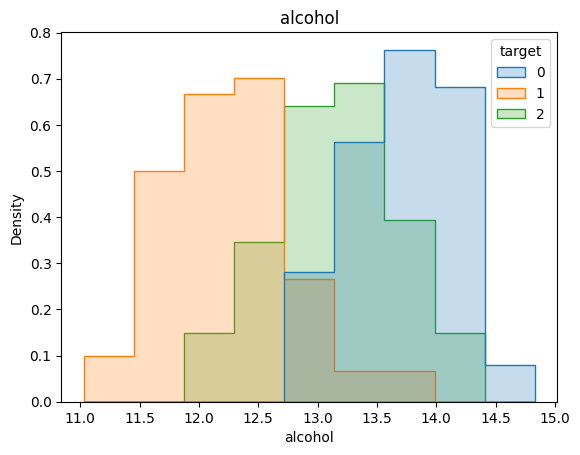

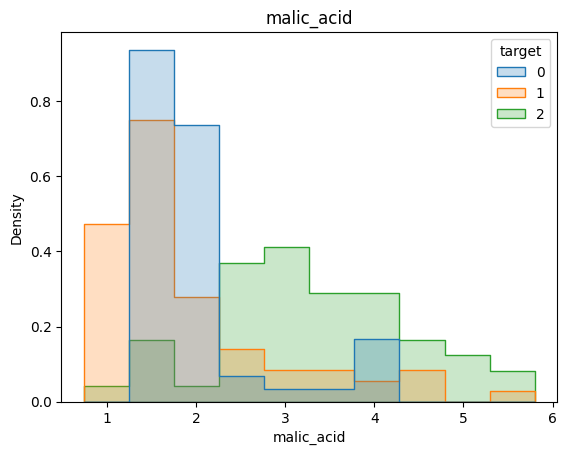

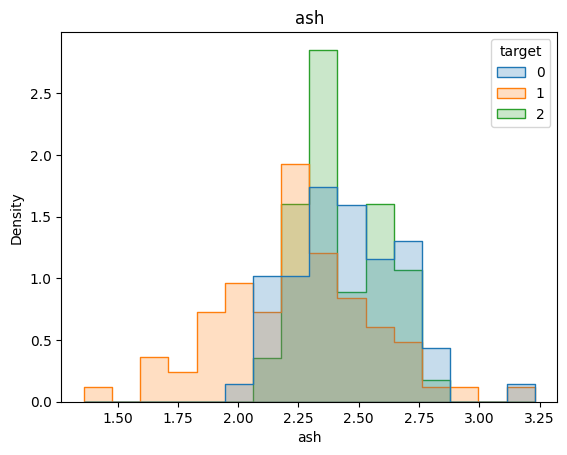

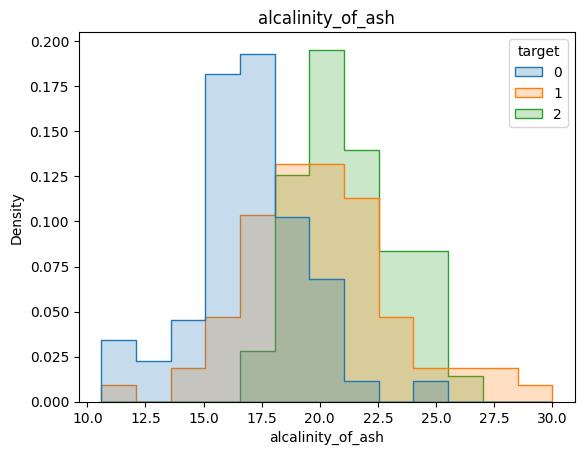

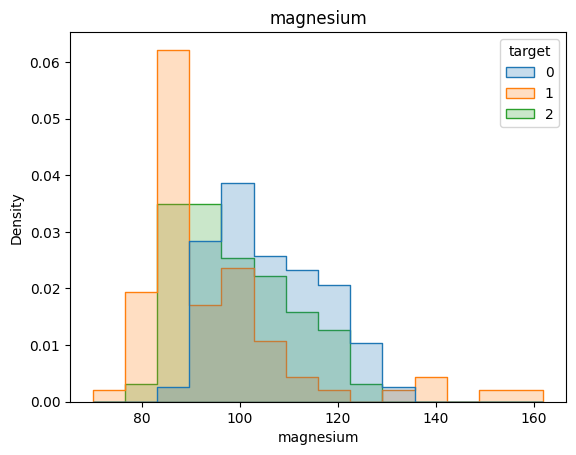

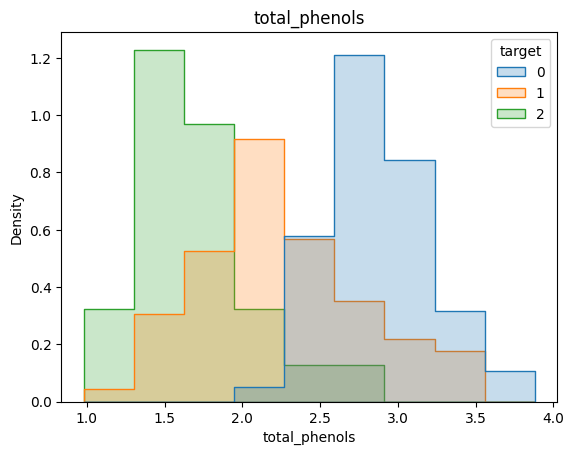

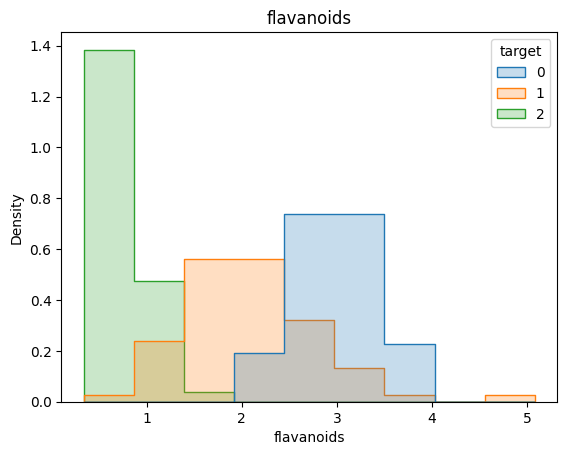

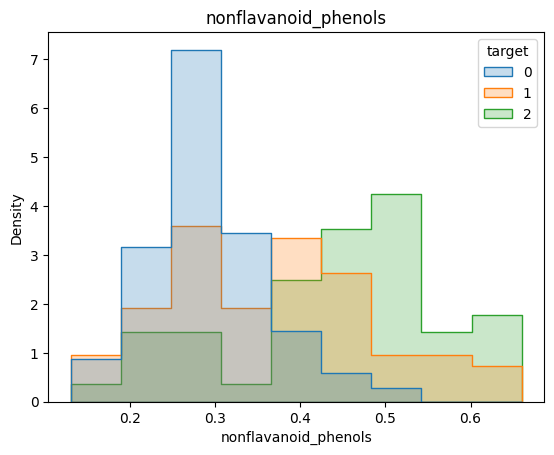

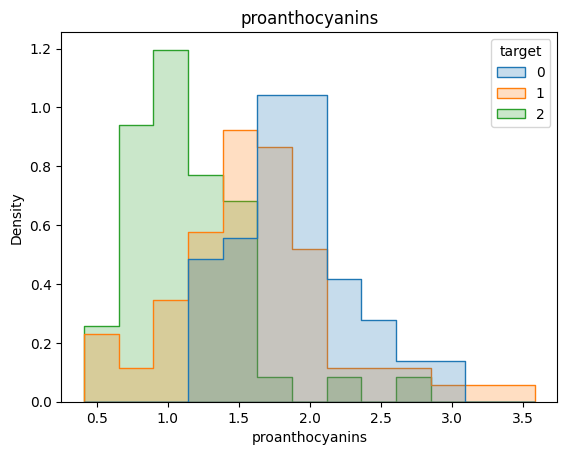

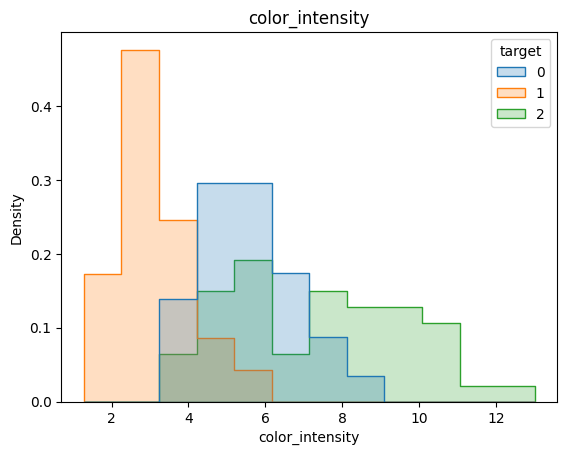

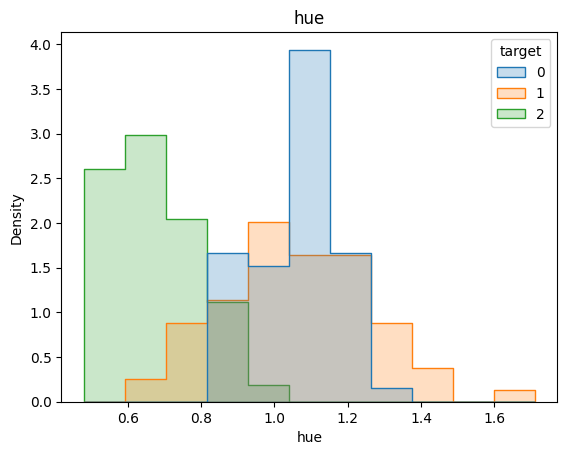

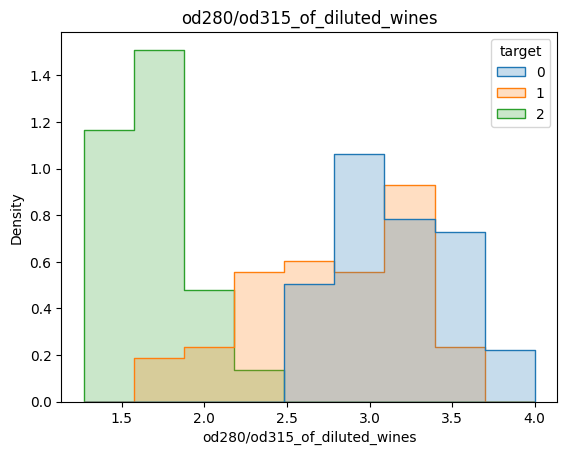

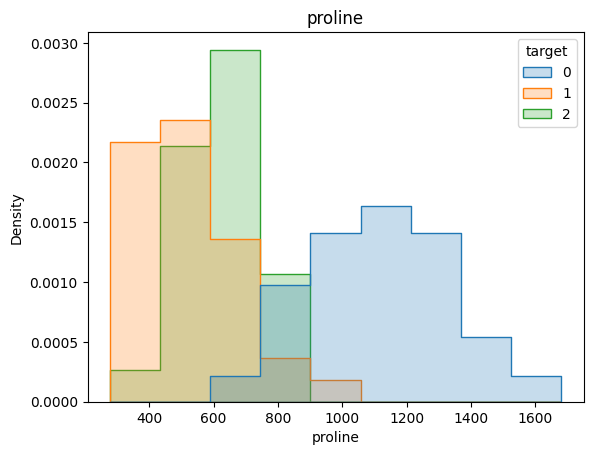

In [8]:
wine_df = pd.DataFrame(X, columns=feature_names)
wine_df['target'] = y

for feature in feature_names:
    sns.histplot(data=wine_df, x=feature, hue='target', element='step', stat='density', common_norm=False, palette='tab10')
    plt.title(feature)
    plt.show()

Пропусков в данных нет, все признаки числовые.

Масштабирование данных будет произведено ниже для сравнения. 

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
print(f"Sizes: X_train - {X_train.shape} , X_test - {X_test.shape}")

Sizes: X_train - (142, 13) , X_test - (36, 13)


In [11]:
def get_metrics(y_test, my_pred_test):
    metrics = {
    "accuracy": accuracy_score(y_test, my_pred_test),
    "precision": precision_score(y_test, my_pred_test, average = 'macro'),
    "recall": recall_score(y_test, my_pred_test, average = 'macro'),
    "f1": f1_score(y_test, my_pred_test, average = 'macro'),
    }
    return metrics

Обучение модели с дефолтными параметрами и полученные метрики:

In [12]:
default_model = KNeighborsClassifier()
default_model.fit(X_train, y_train)
default_preds = default_model.predict(X_test)
default_metrics = get_metrics(y_test, default_preds)

In [13]:
less_n_model = KNeighborsClassifier(n_neighbors=3)
less_n_model.fit(X_train, y_train)
less_n_preds = less_n_model.predict(X_test)
less_n_metrics = get_metrics(y_test, less_n_preds)

In [14]:
more_n_model = KNeighborsClassifier(n_neighbors=7)
more_n_model.fit(X_train, y_train)
more_n_preds = more_n_model.predict(X_test)
more_n_metrics = get_metrics(y_test, more_n_preds)

In [15]:
distance_model = KNeighborsClassifier(weights='distance')
distance_model.fit(X_train, y_train)
distance_preds = distance_model.predict(X_test)
distance_metrics = get_metrics(y_test, distance_preds)

In [16]:
euclidean_model = KNeighborsClassifier(metric='euclidean')
euclidean_model.fit(X_train, y_train)
euclidean_preds = euclidean_model.predict(X_test)
euclidean_metrics = get_metrics(y_test, euclidean_preds)

In [17]:
manhattan_model = KNeighborsClassifier(metric='manhattan')
manhattan_model.fit(X_train, y_train)
manhattan_preds = manhattan_model.predict(X_test)
manhattan_metrics = get_metrics(y_test, manhattan_preds)

In [18]:
comparison_df = pd.DataFrame({
    "Default": default_metrics,
    "less_n(3)" : less_n_metrics,
    "more_n(7)" : more_n_metrics,
    "distance" : distance_metrics,
    "euclidean" : euclidean_metrics,
    "manhattan" : manhattan_metrics
}).T 

Таблица сравнения метрик для разных параметров модели на НЕ масштабированных данных

In [19]:
comparison_df.head(6)

,accuracy,precision,recall,f1
Default,0.805556,0.801865,0.804762,0.802469
less_n(3),0.750000,0.735714,0.747619,0.738462
more_n(7),0.722222,0.716783,0.723810,0.715152
distance,0.805556,0.801865,0.804762,0.802469
euclidean,0.805556,0.801865,0.804762,0.802469
manhattan,0.833333,0.828571,0.828571,0.828571


Лучшие показатели у KNN при n_neighbors=5, weights='uniform', metric='manhattan' - f1=0.83

Теперь масштабируем данные и оценим новые метрики

Нормализация:

In [20]:
mms = MinMaxScaler()
X_train_norm = pd.DataFrame(
    mms.fit_transform(X_train),
    columns=feature_names,
)
X_test_norm = pd.DataFrame(
    mms.transform(X_test),
    columns=feature_names,
)

In [21]:
default_model = KNeighborsClassifier()
default_model.fit(X_train_norm, y_train)
default_preds = default_model.predict(X_test_norm)
default_metrics = get_metrics(y_test, default_preds)

In [22]:
less_n_model = KNeighborsClassifier(n_neighbors=3)
less_n_model.fit(X_train_norm, y_train)
less_n_preds = less_n_model.predict(X_test_norm)
less_n_metrics = get_metrics(y_test, less_n_preds)

In [23]:
more_n_model = KNeighborsClassifier(n_neighbors=7)
more_n_model.fit(X_train_norm, y_train)
more_n_preds = more_n_model.predict(X_test_norm)
more_n_metrics = get_metrics(y_test, more_n_preds)

In [24]:
distance_model = KNeighborsClassifier(weights='distance')
distance_model.fit(X_train_norm, y_train)
distance_preds = distance_model.predict(X_test_norm)
distance_metrics = get_metrics(y_test, distance_preds)

In [25]:
euclidean_model = KNeighborsClassifier(metric='euclidean')
euclidean_model.fit(X_train_norm, y_train)
euclidean_preds = euclidean_model.predict(X_test_norm)
euclidean_metrics = get_metrics(y_test, euclidean_preds)

In [26]:
manhattan_model = KNeighborsClassifier(metric='manhattan')
manhattan_model.fit(X_train_norm, y_train)
manhattan_preds = manhattan_model.predict(X_test_norm)
manhattan_metrics = get_metrics(y_test, manhattan_preds)

In [27]:
comparison_normalized_df = pd.DataFrame({
    "Default": default_metrics,
    "less_n(3)" : less_n_metrics,
    "more_n(7)" : more_n_metrics,
    "distance" : distance_metrics,
    "euclidean" : euclidean_metrics,
    "manhattan" : manhattan_metrics
}).T 

In [28]:
comparison_normalized_df.head(6)

,accuracy,precision,recall,f1
Default,1.000000,1.000000,1.00000,1.000000
less_n(3),0.972222,0.974359,0.97619,0.974321
more_n(7),1.000000,1.000000,1.00000,1.000000
distance,1.000000,1.000000,1.00000,1.000000
euclidean,1.000000,1.000000,1.00000,1.000000
manhattan,0.972222,0.974359,0.97619,0.974321


После нормализации данных модели с идентичными параметрами показали значительный рост точности, а некотрые достигли 100%

## Выводы:
- При малом числе рассматриваемых соседей возрастает риск переобучения, так как модель начинает чрезмерно подстраиваться под обучающую выборку.
- При большом числе - наоборот: происходит сглаживание границ.
- При 'uniform' весах все соседи имеют одинаковый вклад при определении класса, при 'distance' - вклад пропорционален близости к рассматриваемому объекту. То  есть, при относительно гладких границах между классами 'distance' веса должны показывать более высокую точность.
- Выбор метрик оказывал влияние на качество модели до её нормализации, что можно связать с разностью в масштабах признаков и способом их вычисления.
- KNN теряет свою эффективность при большом числе признаков, так как расстояния теряют информативность.
- KNN чувствителен к выбросам.
